<a href="https://colab.research.google.com/github/sandyy221/244107020029_PemMes/blob/main/Tugas_KMeansEuclidian.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

0. Setup Awal

In [ ]:
import os
import time
import tracemalloc
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')

plt.style.use(
    'seaborn-v0_8-whitegrid'
    if 'seaborn-v0_8-whitegrid' in plt.style.available
    else 'default'
)

plt.rcParams['figure.dpi'] = 120

OUTPUT_DIR = 'outputKmeans'
os.makedirs(OUTPUT_DIR, exist_ok=True)

1. Data Understanding

1.1 Load Dataset

In [ ]:
df = pd.read_csv('burnout_dataset1.csv')

print(f'Jumlah data awal: {len(df)}')

# df = df.sample(
#     n=5000,
#     random_state=42
# ).reset_index(drop=True)

print(f'Jumlah data setelah sampling: {len(df)}')

df.head()

Jumlah data awal: 50000
Jumlah data setelah sampling: 50000


,Person_ID,Age,Gender,Country,Occupation,Education_Level,Employment_Status,Monthly_Income_USD,Work_Hours_Per_Week,Remote_Work,...,Family_History_Mental_Illness,Therapy_Attendance,Support_System,Life_Satisfaction,Productivity_Score,Absenteeism_Days,Burnout_Score,Mental_Health_Status,AI_Wellness_Recommendation,Burnout_Risk
0,1,58.0,Male,United States,Marketing Manager,Diploma,Employed,2786.0,67,Hybrid,...,No,Yes,Average,6.0,19.0,2,82,Critical,Practice Mindfulness,High
1,2,24.0,Female,Pakistan,Freelancer,Bachelor,Student,8027.0,44,Hybrid,...,Yes,No,Good,4.0,27.0,22,64,Critical,Reduce Workload,Moderate
2,3,59.0,Male,Malaysia,Accountant,PhD,Employed,3177.0,60,No,...,Yes,No,Average,4.0,51.0,17,50,Needs Attention,Increase Physical Activity,Moderate
3,4,65.0,Other,Mexico,Chef,Master,Self-Employed,4093.0,25,Yes,...,No,Yes,Good,7.0,83.0,14,16,Healthy,Maintain Healthy Routine,Low
4,5,64.0,Other,Japan,Farmer,Diploma,Student,NaN,52,No,...,Yes,No,Poor,9.0,61.0,4,26,Healthy,Reduce Workload,Low


1.2 Data Preview

In [ ]:
print("5 Baris Pertama Dataset:")
display(df.head())

print("\nNama Semua Kolom:")
print(df.columns.tolist())

5 Baris Pertama Dataset:


,Person_ID,Age,Gender,Country,Occupation,Education_Level,Employment_Status,Monthly_Income_USD,Work_Hours_Per_Week,Remote_Work,...,Family_History_Mental_Illness,Therapy_Attendance,Support_System,Life_Satisfaction,Productivity_Score,Absenteeism_Days,Burnout_Score,Mental_Health_Status,AI_Wellness_Recommendation,Burnout_Risk
0,1,58.0,Male,United States,Marketing Manager,Diploma,Employed,2786.0,67,Hybrid,...,No,Yes,Average,6.0,19.0,2,82,Critical,Practice Mindfulness,High
1,2,24.0,Female,Pakistan,Freelancer,Bachelor,Student,8027.0,44,Hybrid,...,Yes,No,Good,4.0,27.0,22,64,Critical,Reduce Workload,Moderate
2,3,59.0,Male,Malaysia,Accountant,PhD,Employed,3177.0,60,No,...,Yes,No,Average,4.0,51.0,17,50,Needs Attention,Increase Physical Activity,Moderate
3,4,65.0,Other,Mexico,Chef,Master,Self-Employed,4093.0,25,Yes,...,No,Yes,Good,7.0,83.0,14,16,Healthy,Maintain Healthy Routine,Low
4,5,64.0,Other,Japan,Farmer,Diploma,Student,NaN,52,No,...,Yes,No,Poor,9.0,61.0,4,26,Healthy,Reduce Workload,Low



Nama Semua Kolom:
['Person_ID', 'Age', 'Gender', 'Country', 'Occupation', 'Education_Level', 'Employment_Status', 'Monthly_Income_USD', 'Work_Hours_Per_Week', 'Remote_Work', 'Job_Satisfaction', 'Work_Life_Balance', 'Sleep_Hours', 'Sleep_Quality', 'Stress_Level', 'Anxiety_Score', 'Depression_Score', 'Mood_Score', 'Emotional_Stability', 'Physical_Activity_Hours', 'Exercise_Frequency', 'Meditation_Minutes', 'Screen_Time_Hours', 'Social_Media_Hours', 'Gaming_Hours', 'Coffee_Cups_Per_Day', 'Alcohol_Consumption', 'Smoking', 'Healthy_Diet', 'Chronic_Stress', 'Family_History_Mental_Illness', 'Therapy_Attendance', 'Support_System', 'Life_Satisfaction', 'Productivity_Score', 'Absenteeism_Days', 'Burnout_Score', 'Mental_Health_Status', 'AI_Wellness_Recommendation', 'Burnout_Risk']


1.3 Tipe data dan Missing Values

In [ ]:
print('Tipe Data:')
print(df.dtypes)

print('\nJumlah Missing Value:')
missing = df.isnull().sum()

missing[missing > 0]

Tipe Data:
Person_ID                          int64
Age                              float64
Gender                            object
Country                           object
Occupation                        object
Education_Level                   object
Employment_Status                 object
Monthly_Income_USD               float64
Work_Hours_Per_Week                int64
Remote_Work                       object
Job_Satisfaction                 float64
Work_Life_Balance                float64
Sleep_Hours                      float64
Sleep_Quality                     object
Stress_Level                      object
Anxiety_Score                    float64
Depression_Score                 float64
Mood_Score                       float64
Emotional_Stability                int64
Physical_Activity_Hours          float64
Exercise_Frequency                object
Meditation_Minutes               float64
Screen_Time_Hours                float64
Social_Media_Hours               float64
Gamin

,0
Age,250
Monthly_Income_USD,1450
Job_Satisfaction,500
Work_Life_Balance,650
Sleep_Hours,950
Anxiety_Score,800
Depression_Score,850
Mood_Score,900
Physical_Activity_Hours,1100
Meditation_Minutes,1200


1.4 Identifikasi Kolom yang Digunakan

In [ ]:
# Kolom numerik asli
numeric_columns = df.select_dtypes(include='number').columns

# Menghapus identifier
numeric_columns = numeric_columns.drop(
    ['Person_ID'],
    errors='ignore'
)

# Kolom kategorikal yang akan di-encoding
categorical_columns = [
    'Remote_Work',
    'Sleep_Quality',
    'Stress_Level',
    'Exercise_Frequency',
    'Alcohol_Consumption',
    'Smoking',
    'Healthy_Diet',
    'Chronic_Stress',
    'Family_History_Mental_Illness',
    'Therapy_Attendance',
    'Support_System',
    'Mental_Health_Status'
]

print('Kolom Numerik:')
print(numeric_columns.tolist())

print('\nKolom Kategorikal yang akan di-encoding:')
print(categorical_columns)

Kolom Numerik:
['Age', 'Monthly_Income_USD', 'Work_Hours_Per_Week', 'Job_Satisfaction', 'Work_Life_Balance', 'Sleep_Hours', 'Anxiety_Score', 'Depression_Score', 'Mood_Score', 'Emotional_Stability', 'Physical_Activity_Hours', 'Meditation_Minutes', 'Screen_Time_Hours', 'Social_Media_Hours', 'Gaming_Hours', 'Coffee_Cups_Per_Day', 'Life_Satisfaction', 'Productivity_Score', 'Absenteeism_Days', 'Burnout_Score']

Kolom Kategorikal yang akan di-encoding:
['Remote_Work', 'Sleep_Quality', 'Stress_Level', 'Exercise_Frequency', 'Alcohol_Consumption', 'Smoking', 'Healthy_Diet', 'Chronic_Stress', 'Family_History_Mental_Illness', 'Therapy_Attendance', 'Support_System', 'Mental_Health_Status']


1.5 Statistik Deskriptif

In [ ]:
df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,49750.0,41.448181,13.871634,18.0,29.0,41.0,53.0,65.0
Monthly_Income_USD,48550.0,6251.281524,3319.661435,500.0,3381.0,6231.0,9134.0,12000.0
Work_Hours_Per_Week,50000.0,44.946160,14.729024,20.0,32.0,45.0,58.0,70.0
Job_Satisfaction,49500.0,5.499051,2.866621,1.0,3.0,6.0,8.0,10.0
Work_Life_Balance,49350.0,5.504397,2.867492,1.0,3.0,6.0,8.0,10.0
Sleep_Hours,49050.0,6.997445,1.728766,4.0,5.5,7.0,8.5,10.0
Anxiety_Score,49200.0,40.449045,26.004291,0.0,19.0,39.0,59.0,100.0
Depression_Score,49150.0,40.601160,26.308933,0.0,19.0,39.0,60.0,100.0
Mood_Score,49100.0,59.622994,25.783486,0.0,41.0,61.0,80.0,100.0
Emotional_Stability,50000.0,59.382100,26.090946,0.0,40.0,60.0,81.0,100.0


1.6 Visualisasi Distribusi Data

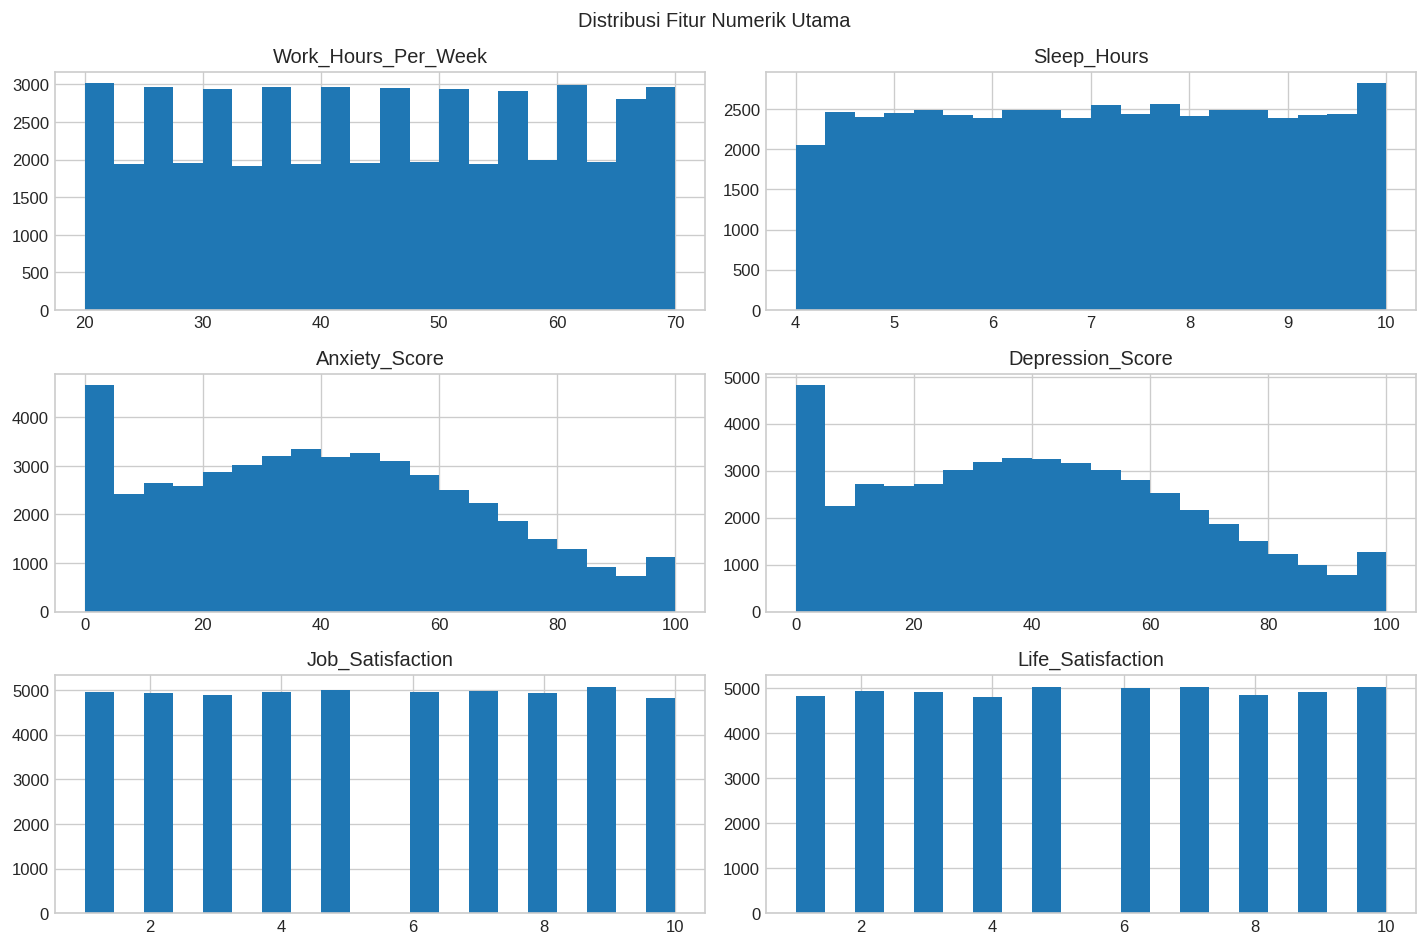

In [ ]:
selected_features = [
    'Work_Hours_Per_Week',
    'Sleep_Hours',
    'Anxiety_Score',
    'Depression_Score',
    'Job_Satisfaction',
    'Life_Satisfaction'
]

df[selected_features].hist(
    figsize=(12, 8),
    bins=20
)

plt.suptitle('Distribusi Fitur Numerik Utama')
plt.tight_layout()
plt.show()

1.7 Visualisasi Deteksi Outlier

In [ ]:
numeric_columns = df.select_dtypes(include='number').columns

numeric_columns = numeric_columns.drop(
    ['person_id', 'Person_ID,', 'Burnout_Score'],
    errors='ignore'
)

numeric_data = df[numeric_columns]

Q1 = numeric_data.quantile(0.25)
Q3 = numeric_data.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = (
    (numeric_data < lower_bound) |
    (numeric_data > upper_bound)
)

In [ ]:
outlier_summary = pd.DataFrame({
    'Jumlah Outlier': outlier_mask.sum(),
    'Persentase (%)': (
        outlier_mask.sum() / len(df) * 100
    ).round(2)
})

outlier_summary = outlier_summary.sort_values(
    'Jumlah Outlier',
    ascending=False
)

outlier_summary

,Jumlah Outlier,Persentase (%)
Person_ID,0,0.0
Age,0,0.0
Monthly_Income_USD,0,0.0
Work_Hours_Per_Week,0,0.0
Job_Satisfaction,0,0.0
Work_Life_Balance,0,0.0
Sleep_Hours,0,0.0
Anxiety_Score,0,0.0
Depression_Score,0,0.0
Mood_Score,0,0.0


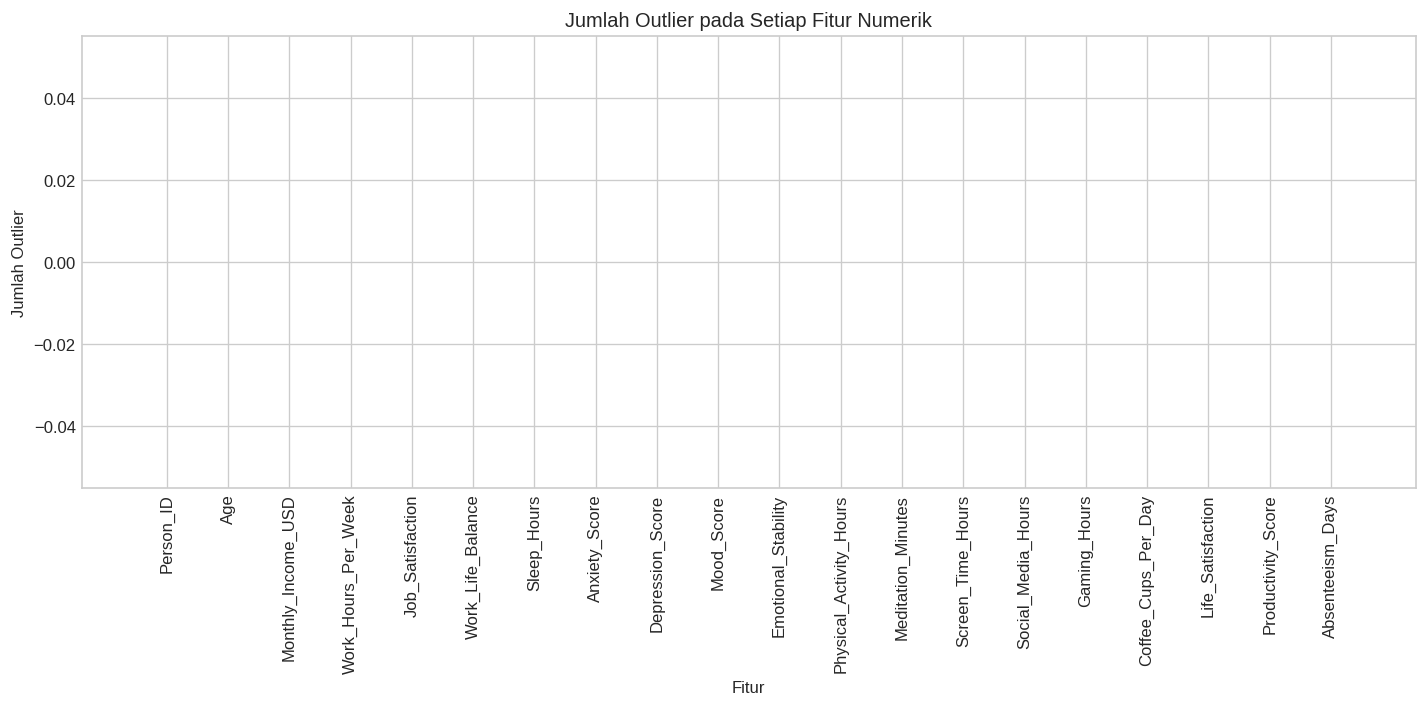

In [ ]:
plt.figure(figsize=(12, 6))

plt.bar(
    outlier_summary.index,
    outlier_summary['Jumlah Outlier']
)

plt.title('Jumlah Outlier pada Setiap Fitur Numerik')
plt.xlabel('Fitur')
plt.ylabel('Jumlah Outlier')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [ ]:
print(outlier_summary)

                         Jumlah Outlier  Persentase (%)
Person_ID                             0             0.0
Age                                   0             0.0
Monthly_Income_USD                    0             0.0
Work_Hours_Per_Week                   0             0.0
Job_Satisfaction                      0             0.0
Work_Life_Balance                     0             0.0
Sleep_Hours                           0             0.0
Anxiety_Score                         0             0.0
Depression_Score                      0             0.0
Mood_Score                            0             0.0
Emotional_Stability                   0             0.0
Physical_Activity_Hours               0             0.0
Meditation_Minutes                    0             0.0
Screen_Time_Hours                     0             0.0
Social_Media_Hours                    0             0.0
Gaming_Hours                          0             0.0
Coffee_Cups_Per_Day                   0         

2.1 Seleksi Kolom

In [ ]:
selected_columns = list(numeric_columns) + categorical_columns

X = df[selected_columns].copy()

X.head()

,Person_ID,Age,Monthly_Income_USD,Work_Hours_Per_Week,Job_Satisfaction,Work_Life_Balance,Sleep_Hours,Anxiety_Score,Depression_Score,Mood_Score,...,Stress_Level,Exercise_Frequency,Alcohol_Consumption,Smoking,Healthy_Diet,Chronic_Stress,Family_History_Mental_Illness,Therapy_Attendance,Support_System,Mental_Health_Status
0,1,58.0,2786.0,67,3.0,7.0,4.6,74.0,75.0,26.0,...,High,Weekly,Yes,Yes,No,Yes,No,Yes,Average,Critical
1,2,24.0,8027.0,44,5.0,8.0,4.7,58.0,80.0,29.0,...,Moderate,Weekly,Yes,Yes,Yes,No,Yes,No,Good,Critical
2,3,59.0,3177.0,60,8.0,7.0,6.3,54.0,55.0,44.0,...,Moderate,Daily,Yes,No,No,No,Yes,No,Average,Needs Attention
3,4,65.0,4093.0,25,2.0,9.0,7.1,12.0,11.0,88.0,...,Low,Weekly,Yes,No,No,No,No,Yes,Good,Healthy
4,5,64.0,NaN,52,1.0,4.0,9.1,25.0,48.0,67.0,...,Low,Never,Yes,No,No,No,Yes,No,Poor,Healthy


2.2 Encoding Data Kategorikal

In [ ]:
encoding_maps = {
    'Remote_Work': {
        'No': 0,
        'Hybrid': 1,
        'Yes': 2
    },

    'Sleep_Quality': {
        'Excellent': 0,
        'Good': 1,
        'Average': 2,
        'Poor': 3
    },

    'Stress_Level': {
        'Low': 0,
        'Moderate': 1,
        'High': 2
    },

    'Exercise_Frequency': {
        'Daily': 0,
        'Weekly': 1,
        'Rarely': 2,
        'Never': 3
    },

    'Alcohol_Consumption': {
        'No': 0,
        'Yes': 1
    },

    'Smoking': {
        'No': 0,
        'Yes': 1
    },

    'Healthy_Diet': {
        'No': 0,
        'Yes': 1
    },

    'Chronic_Stress': {
        'No': 0,
        'Yes': 1
    },

    'Family_History_Mental_Illness': {
        'No': 0,
        'Yes': 1
    },

    'Therapy_Attendance': {
        'No': 0,
        'Yes': 1
    },

    'Support_System': {
        'Poor': 0,
        'Average': 1,
        'Good': 2,
        'Excellent': 3
    },

    'Mental_Health_Status': {
        'Healthy': 0,
        'Needs Attention': 1,
        'Critical': 2
    }
}

for column, mapping in encoding_maps.items():
    X[column] = X[column].map(mapping)

X[categorical_columns].head()

,Remote_Work,Sleep_Quality,Stress_Level,Exercise_Frequency,Alcohol_Consumption,Smoking,Healthy_Diet,Chronic_Stress,Family_History_Mental_Illness,Therapy_Attendance,Support_System,Mental_Health_Status
0,1,3,2,1,1,1,0,1,0,1.0,1,2
1,1,3,1,1,1,1,1,0,1,0.0,2,2
2,0,2,1,0,1,0,0,0,1,0.0,1,1
3,2,1,0,1,1,0,0,0,0,1.0,2,0
4,0,0,0,3,1,0,0,0,1,0.0,0,0


2.3 Penanganan Missing Values

In [ ]:
print('Missing value sebelum preprocessing:')
print(X.isnull().sum())

X = X.fillna(X.median())

print(
    '\nJumlah missing value setelah preprocessing:',
    X.isnull().sum().sum()
)

Missing value sebelum preprocessing:
Person_ID                           0
Age                               250
Monthly_Income_USD               1450
Work_Hours_Per_Week                 0
Job_Satisfaction                  500
Work_Life_Balance                 650
Sleep_Hours                       950
Anxiety_Score                     800
Depression_Score                  850
Mood_Score                        900
Emotional_Stability                 0
Physical_Activity_Hours          1100
Meditation_Minutes               1200
Screen_Time_Hours                 850
Social_Media_Hours                600
Gaming_Hours                      750
Coffee_Cups_Per_Day                 0
Life_Satisfaction                 700
Productivity_Score                950
Absenteeism_Days                    0
Remote_Work                         0
Sleep_Quality                       0
Stress_Level                        0
Exercise_Frequency                  0
Alcohol_Consumption                 0
Smoking      

2.4 Penanganan Outlier

In [ ]:
# Karena tidak, tidak dilakukan

2.5 Standardisasi

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns,
    index=X.index
)

X_scaled

,Person_ID,Age,Monthly_Income_USD,Work_Hours_Per_Week,Job_Satisfaction,Work_Life_Balance,Sleep_Hours,Anxiety_Score,Depression_Score,Mood_Score,...,Stress_Level,Exercise_Frequency,Alcohol_Consumption,Smoking,Healthy_Diet,Chronic_Stress,Family_History_Mental_Illness,Therapy_Attendance,Support_System,Mental_Health_Status
0,-1.732016,1.196378,-1.059170,1.497320,-0.877799,0.522638,-1.400203,1.301535,1.319769,-1.316899,...,1.838578,-0.455507,1.008436,1.003687,-0.996685,2.53389,-0.996765,1.016577,-0.441976,1.633584
1,-1.731947,-1.260836,0.543024,-0.064238,-0.176698,0.873599,-1.341801,0.681279,1.511451,-1.199485,...,0.411952,-0.455507,1.008436,1.003687,1.003326,-0.39465,1.003245,-0.983693,0.452894,1.633584
2,-1.731878,1.268649,-0.939640,1.022063,0.874952,0.522638,-0.407356,0.526215,0.553042,-0.612419,...,0.411952,-1.351150,1.008436,-0.996327,-0.996685,-0.39465,1.003245,-0.983693,-0.441976,0.373764
3,-1.731808,1.702275,-0.659615,-1.354221,-1.228349,1.224560,0.059866,-1.101957,-1.133757,1.109642,...,-1.014673,-0.455507,1.008436,-0.996327,-0.996685,-0.39465,-0.996765,1.016577,0.452894,-0.886057
4,-1.731739,1.630004,-0.006020,0.478912,-1.578899,-0.530247,1.227922,-0.597999,0.284688,0.287749,...,-1.014673,1.335781,1.008436,-0.996327,-0.996685,-0.39465,1.003245,-0.983693,-1.336847,-0.886057
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,1.731739,-0.393584,-0.828669,-0.132132,0.874952,0.171676,0.001464,0.642513,0.323024,-0.573281,...,0.411952,-0.455507,1.008436,-0.996327,1.003326,-0.39465,1.003245,-0.983693,-0.441976,0.373764
49996,1.731808,1.124107,1.338771,-1.422115,-1.228349,0.171676,-1.575412,-1.334553,-1.555457,1.305331,...,-1.014673,-1.351150,1.008436,1.003687,-0.996685,-0.39465,-0.996765,1.016577,1.347764,-0.886057
49997,1.731878,-0.538126,-0.950034,0.750488,0.874952,-1.232169,0.351880,0.952641,1.434779,-1.042934,...,0.411952,1.335781,1.008436,-0.996327,1.003326,-0.39465,-0.996765,1.016577,-1.336847,1.633584
49998,1.731947,1.413191,-0.754995,-1.082646,-0.176698,0.522638,0.001464,-0.326637,-0.903739,0.561714,...,-1.014673,1.335781,1.008436,1.003687,-0.996685,-0.39465,-0.996765,1.016577,-1.336847,-0.886057


2.6 Data Bersih

In [ ]:
print('Dimensi data setelah preprocessing:', X.shape)
print('Jumlah missing value:', X.isnull().sum().sum())

X_scaled.head()

Dimensi data setelah preprocessing: (50000, 32)
Jumlah missing value: 0


,Person_ID,Age,Monthly_Income_USD,Work_Hours_Per_Week,Job_Satisfaction,Work_Life_Balance,Sleep_Hours,Anxiety_Score,Depression_Score,Mood_Score,...,Stress_Level,Exercise_Frequency,Alcohol_Consumption,Smoking,Healthy_Diet,Chronic_Stress,Family_History_Mental_Illness,Therapy_Attendance,Support_System,Mental_Health_Status
0,-1.732016,1.196378,-1.059170,1.497320,-0.877799,0.522638,-1.400203,1.301535,1.319769,-1.316899,...,1.838578,-0.455507,1.008436,1.003687,-0.996685,2.53389,-0.996765,1.016577,-0.441976,1.633584
1,-1.731947,-1.260836,0.543024,-0.064238,-0.176698,0.873599,-1.341801,0.681279,1.511451,-1.199485,...,0.411952,-0.455507,1.008436,1.003687,1.003326,-0.39465,1.003245,-0.983693,0.452894,1.633584
2,-1.731878,1.268649,-0.939640,1.022063,0.874952,0.522638,-0.407356,0.526215,0.553042,-0.612419,...,0.411952,-1.351150,1.008436,-0.996327,-0.996685,-0.39465,1.003245,-0.983693,-0.441976,0.373764
3,-1.731808,1.702275,-0.659615,-1.354221,-1.228349,1.224560,0.059866,-1.101957,-1.133757,1.109642,...,-1.014673,-0.455507,1.008436,-0.996327,-0.996685,-0.39465,-0.996765,1.016577,0.452894,-0.886057
4,-1.731739,1.630004,-0.006020,0.478912,-1.578899,-0.530247,1.227922,-0.597999,0.284688,0.287749,...,-1.014673,1.335781,1.008436,-0.996327,-0.996685,-0.39465,1.003245,-0.983693,-1.336847,-0.886057


3. Modeling

3.1 Penentuan Jumlah Klaster dengan Elbow Method

In [ ]:
k_values = list(range(1, 11))
sse = []

for k in k_values:
    model_test = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        random_state=42
    )

    model_test.fit(X_scaled)

    sse.append(model_test.inertia_)

In [ ]:
p1 = np.array([
    k_values[0],
    sse[0]
])

p2 = np.array([
    k_values[-1],
    sse[-1]
])

line_vec = p2 - p1
line_unit = line_vec / np.linalg.norm(line_vec)

distances = []

for k, inertia in zip(k_values, sse):

    point = np.array([
        k,
        inertia
    ])

    vec = point - p1

    projection = (
        np.dot(vec, line_unit)
        * line_unit
    )

    perpendicular = vec - projection

    distances.append(
        np.linalg.norm(perpendicular)
    )

n_clusters = k_values[
    np.argmax(distances)
]

print(
    f'Jumlah Cluster Optimal: k = {n_clusters}'
)

Jumlah Cluster Optimal: k = 3


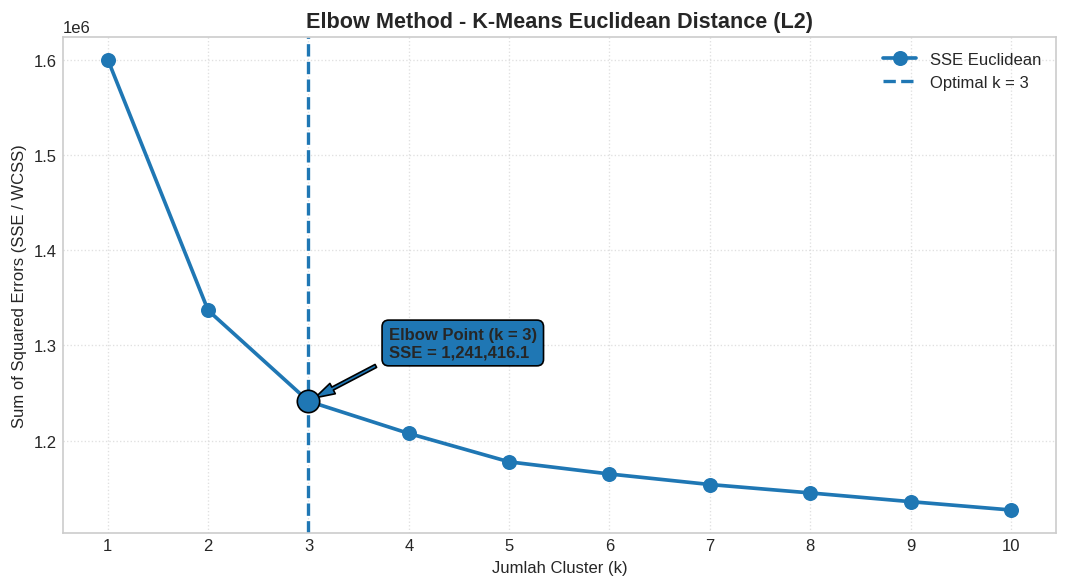

In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(
    k_values,
    sse,
    marker='o',
    markersize=8,
    linewidth=2.2,
    label='SSE Euclidean'
)

plt.axvline(
    x=n_clusters,
    linestyle='--',
    linewidth=2,
    label=f'Optimal k = {n_clusters}'
)

plt.scatter(
    [n_clusters],
    [sse[n_clusters - 1]],
    s=180,
    zorder=5,
    edgecolor='black'
)

plt.title(
    'Elbow Method - K-Means Euclidean Distance (L2)',
    fontsize=13,
    fontweight='bold'
)

plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Sum of Squared Errors (SSE / WCSS)')
plt.xticks(k_values)

plt.annotate(
    f'Elbow Point (k = {n_clusters})\n'
    f'SSE = {sse[n_clusters - 1]:,.1f}',
    xy=(
        n_clusters,
        sse[n_clusters - 1]
    ),
    xytext=(
        n_clusters + 0.8,
        sse[n_clusters - 1]
        + (max(sse) - min(sse)) * 0.1
    ),
    arrowprops=dict(
        shrink=0.08,
        width=2,
        headwidth=7
    ),
    bbox=dict(
        boxstyle='round,pad=0.4'
    ),
    fontweight='bold'
)

plt.grid(
    True,
    linestyle=':',
    alpha=0.6
)

plt.legend()
plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        'elbow_euclidean.png'
    ),
    dpi=300
)

plt.show()

3.2 Training K-Means Euclidian

In [ ]:
tracemalloc.start()

start_time = time.perf_counter()

kmeans = KMeans(
    n_clusters=n_clusters,
    init='k-means++',
    n_init=10,
    max_iter=300,
    tol=1e-4,
    random_state=42
)

kmeans.fit(X_scaled)

runtime = (
    time.perf_counter()
    - start_time
)

current_memory, peak_memory = (
    tracemalloc.get_traced_memory()
)

tracemalloc.stop()

peak_memory_mb = (
    peak_memory / (1024 ** 2)
)

labels = kmeans.labels_

df['KMeans_Cluster'] = labels

In [ ]:
iterations = kmeans.n_iter_
sse_final = kmeans.inertia_

print(
    f'Runtime     : {runtime:.5f} detik'
)

print(
    f'Iterations  : {iterations}'
)

print(
    f'SSE         : {sse_final:.2f}'
)

print(
    f'Peak Memory : {peak_memory_mb:.2f} MB'
)

Runtime     : 0.95786 detik
Iterations  : 8
SSE         : 1241416.11
Peak Memory : 24.48 MB


4. Evaluasi

4.1 Silhouette Score

In [ ]:
silhouette = float(
    silhouette_score(
        X_scaled,
        labels,
        metric='euclidean'
    )
)

print(
    f'Silhouette Score: '
    f'{silhouette:.4f}'
)

Silhouette Score: 0.1078


4.2 Davies-Bouldin Index

In [ ]:
db_index = float(
    davies_bouldin_score(
        X_scaled,
        labels
    )
)

print(
    f'Davies-Bouldin Index: '
    f'{db_index:.4f}'
)

Davies-Bouldin Index: 2.5410


4.3 Calinski-Harabasz Index

In [ ]:
ch_index = float(
    calinski_harabasz_score(
        X_scaled,
        labels
    )
)

print(
    f'Calinski-Harabasz Index: '
    f'{ch_index:.2f}'
)

Calinski-Harabasz Index: 7220.83


4.4 Distribusi Cluster

In [ ]:
cluster_distribution = (
    df['KMeans_Cluster']
    .value_counts()
    .sort_index()
)

cluster_distribution

,count
KMeans_Cluster,
0,21760
1,6786
2,21454


4.5 Ringkasan Evaluasi

In [ ]:
model_summary = pd.DataFrame([{
    'Model': 'K-Means Euclidean',

    'Distance Metric':
        'Euclidean Distance (L2)',

    'Jumlah Cluster':
        n_clusters,

    'Silhouette Score (↑)':
        round(silhouette, 4),

    'Davies-Bouldin Index (↓)':
        round(db_index, 4),

    'Calinski-Harabasz Index (↑)':
        round(ch_index, 2),

    'Execution Time (s) (↓)':
        round(runtime, 5),

    'Iterations (↓)':
        iterations,

    'Objective Value (SSE) (↓)':
        round(sse_final, 2),

    'Alokasi Memori (MB)':
        round(peak_memory_mb, 2)
}])

model_summary

,Model,Distance Metric,Jumlah Cluster,Silhouette Score (↑),Davies-Bouldin Index (↓),Calinski-Harabasz Index (↑),Execution Time (s) (↓),Iterations (↓),Objective Value (SSE) (↓),Alokasi Memori (MB)
0,K-Means Euclidean,Euclidean Distance (L2),3,0.1078,2.541,7220.83,0.95786,8,1241416.11,24.48


4.6 Export Hasil

In [ ]:
excel_path = os.path.join(
    OUTPUT_DIR,
    'evaluasi_kmeans_euclidean.xlsx'
)

df_clustered = df.copy()

df_clustered[
    'KMeans_Cluster'
] = labels

with pd.ExcelWriter(
    excel_path,
    engine='openpyxl'
) as writer:

    model_summary.to_excel(
        writer,
        sheet_name='Ringkasan_Evaluasi',
        index=False
    )

    df_clustered.to_excel(
        writer,
        sheet_name='Data_Terklaster',
        index=False
    )

print(
    f'Hasil disimpan ke: {excel_path}'
)

Hasil disimpan ke: outputKmeans/evaluasi_kmeans_euclidean.xlsx


5. Reduksi Dimensi PCA

5.1 PCA

In [ ]:
pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(
    X_scaled
)

centroids_pca = pca.transform(
    kmeans.cluster_centers_
)

5.2 Visualisasi Hasil Klaster

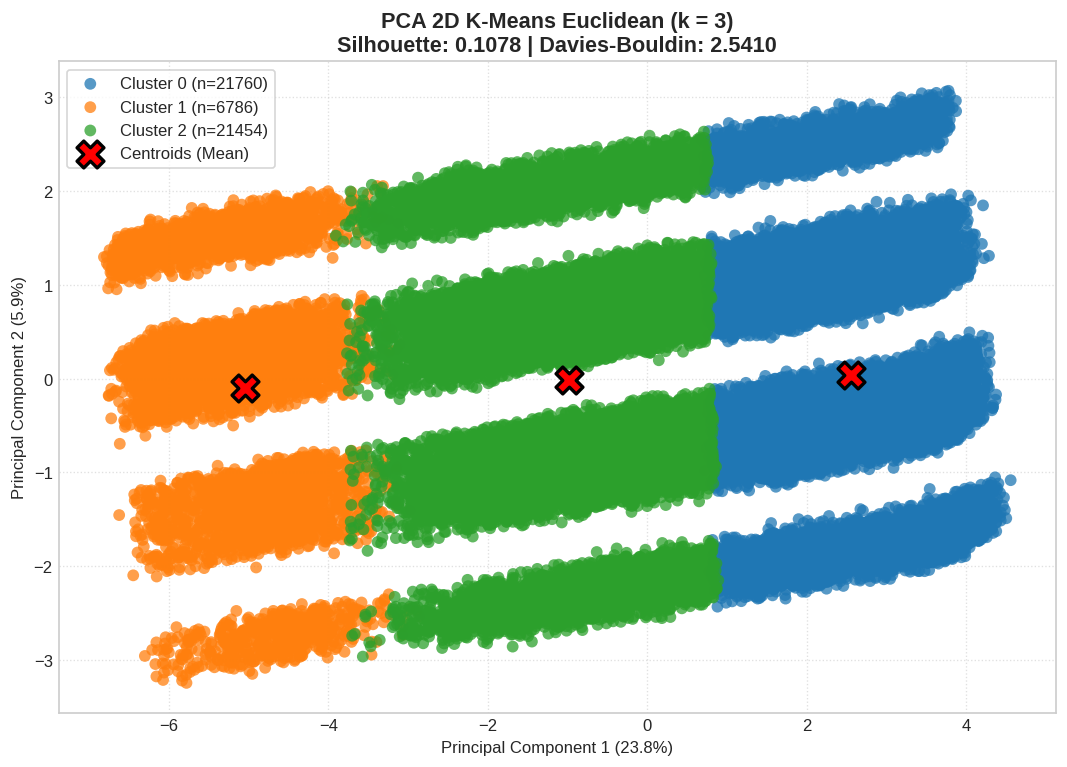

In [ ]:
plt.figure(
    figsize=(9, 6.5)
)

palette = sns.color_palette(
    'tab10',
    n_clusters
)

for k in range(n_clusters):

    mask = labels == k

    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        color=palette[k],
        label=(
            f'Cluster {k} '
            f'(n={np.sum(mask)})'
        ),
        alpha=0.75,
        s=50,
        edgecolors='none'
    )

plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    marker='X',
    s=260,
    c='red',
    edgecolor='black',
    linewidth=2,
    label='Centroids (Mean)',
    zorder=10
)

plt.title(
    f'PCA 2D K-Means Euclidean '
    f'(k = {n_clusters})\n'
    f'Silhouette: {silhouette:.4f} | '
    f'Davies-Bouldin: {db_index:.4f}',
    fontsize=13,
    fontweight='bold'
)

plt.xlabel(
    'Principal Component 1 '
    f'({pca.explained_variance_ratio_[0] * 100:.1f}%)'
)

plt.ylabel(
    'Principal Component 2 '
    f'({pca.explained_variance_ratio_[1] * 100:.1f}%)'
)

plt.grid(
    True,
    linestyle=':',
    alpha=0.6
)

plt.legend(
    frameon=True,
    loc='best'
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        'cluster_euclidean.png'
    ),
    dpi=300
)

plt.show()

6. Analisis

6.1 Profil Cluster

In [ ]:
df_analysis = X.copy()

df_analysis['KMeans_Cluster'] = labels

cluster_profile = (
    df_analysis
    .groupby('KMeans_Cluster')
    .mean()
)

cluster_profile

,Person_ID,Age,Monthly_Income_USD,Work_Hours_Per_Week,Job_Satisfaction,Work_Life_Balance,Sleep_Hours,Anxiety_Score,Depression_Score,Mood_Score,...,Stress_Level,Exercise_Frequency,Alcohol_Consumption,Smoking,Healthy_Diet,Chronic_Stress,Family_History_Mental_Illness,Therapy_Attendance,Support_System,Mental_Health_Status
KMeans_Cluster,,,,,,,,,,,,,,,,,,,,,
0,25064.959191,41.457353,6282.425689,35.659375,5.536075,5.502941,7.380887,17.056664,17.440028,82.851103,...,0.027803,1.503722,0.492463,0.493107,0.501517,0.000000,0.494531,0.492463,1.483824,0.038511
1,24779.272767,41.440466,6236.244621,59.872237,5.564545,5.547303,6.305187,81.811082,81.721485,18.419393,...,2.000000,1.536104,0.502653,0.498084,0.480696,0.992927,0.499116,0.491306,1.497937,1.961686
2,25005.096625,41.436096,6223.078633,49.644216,5.452456,5.507318,6.827613,51.038035,51.022653,49.154237,...,0.996784,1.504801,0.497017,0.503309,0.500699,0.000000,0.502051,0.491237,1.502843,0.979584


6.2 Perbandingan Cluster dengan Burnout Risk

In [ ]:
comparison = pd.crosstab(
    df['KMeans_Cluster'],
    df['Burnout_Risk']
)

comparison

comparison_percentage = pd.crosstab(
    df['KMeans_Cluster'],
    df['Burnout_Risk'],
    normalize='index'
) * 100

comparison_percentage.round(2)

Burnout_Risk,High,Low,Moderate
KMeans_Cluster,,,
0,0.00,96.15,3.85
1,91.76,0.00,8.24
2,16.89,20.73,62.38


6.3 Analisis Centroid

In [ ]:
centroid_original = scaler.inverse_transform(
    kmeans.cluster_centers_
)

centroid_original = pd.DataFrame(
    centroid_original,
    columns=X.columns
)

centroid_original.index.name = 'Cluster'

centroid_original

,Person_ID,Age,Monthly_Income_USD,Work_Hours_Per_Week,Job_Satisfaction,Work_Life_Balance,Sleep_Hours,Anxiety_Score,Depression_Score,Mood_Score,...,Stress_Level,Exercise_Frequency,Alcohol_Consumption,Smoking,Healthy_Diet,Chronic_Stress,Family_History_Mental_Illness,Therapy_Attendance,Support_System,Mental_Health_Status
Cluster,,,,,,,,,,,,,,,,,,,,,
0,25066.744793,41.458646,6282.525953,35.653303,5.536113,5.502644,7.380723,17.051124,17.434509,82.859593,...,0.027585,1.503885,0.492529,0.493173,0.501586,4.571343e-14,0.494506,0.492391,1.483932,0.038389
1,24779.272767,41.440466,6236.244621,59.872237,5.564545,5.547303,6.305187,81.811082,81.721485,18.419393,...,2.000000,1.536104,0.502653,0.498084,0.480696,9.929266e-01,0.499116,0.491306,1.497937,1.961686
2,25003.312165,41.434795,6223.001910,49.644504,5.452453,5.507618,6.828011,51.029399,51.014164,49.159763,...,0.996599,1.504636,0.496948,0.503238,0.500629,4.490852e-14,0.502073,0.491311,1.502726,0.979313
